# Lesson 3 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/3/3-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
to return. Replace `raise NotImplementedError` with your implementation;
the cell after it asserts the behaviour.

**A failing assert is information, not a grade.**

The written questions are marked and they carry the real learning
objective. Every one asks you to **run something both ways and explain
the difference** using numbers you produced. For each hyperparameter you
are asked about, say explicitly **which direction is underfitting, which
is overfitting, and what the metric does at each extreme**.

Every function you need is demonstrated in `3-practice.ipynb`, and each
task names the section.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`3-homework-results.ipynb`, and commit it to your fork under
`practice/3/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [1]:
import sys
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| scikit-learn", sklearn.__version__)

python 3.13.15 | scikit-learn 1.6.1


In [2]:
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, GridSearchCV)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             silhouette_score, adjusted_rand_score)

titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
iris = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/iris.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| iris", iris.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | iris (150, 6) | bikes (17379, 17)


## 2. Task 1 — Regression metrics from their definitions

Mechanical. Do not call scikit-learn's metric functions; build them from
the errors.

*see Practice 3 §4.2*

In [3]:
def regression_metrics(y_true, y_pred):
    """Return a dict with keys 'mse', 'rmse', 'mae', 'r2'.

        mse  = mean of the squared errors
        rmse = square root of mse
        mae  = mean of the absolute errors
        r2   = 1 - (sum of squared errors) / (sum of squared deviations
               of y_true from its own mean)

    Return Python/NumPy floats. Do not import from sklearn.metrics.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    errors = y_true - y_pred

    mse = np.mean(errors ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(errors))

    ss_res = np.sum(errors ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot

    return {
        "mse": float(mse),
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2)
    }

In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

_truth = np.array([10.0, 20.0, 30.0, 40.0, 50.0])
_guess = np.array([12.0, 18.0, 33.0, 39.0, 54.0])
_m = regression_metrics(_truth, _guess)

assert set(_m) == {"mse", "rmse", "mae", "r2"}
assert np.isclose(_m["mse"], mean_squared_error(_truth, _guess)), f"mse wrong: {_m['mse']}"
assert np.isclose(_m["rmse"], np.sqrt(mean_squared_error(_truth, _guess)))
assert np.isclose(_m["mae"], mean_absolute_error(_truth, _guess)), f"mae wrong: {_m['mae']}"
assert np.isclose(_m["r2"], r2_score(_truth, _guess)), f"r2 wrong: {_m['r2']}"

# A perfect prediction: zero error, R^2 exactly 1.
_perfect = regression_metrics(_truth, _truth)
assert np.isclose(_perfect["mse"], 0.0) and np.isclose(_perfect["r2"], 1.0)

# Predicting the mean every time gives R^2 of exactly 0, by construction.
_mean_only = regression_metrics(_truth, np.full_like(_truth, _truth.mean()))
assert np.isclose(_mean_only["r2"], 0.0), \
    f"always predicting the mean must give R^2 = 0, you got {_mean_only['r2']}"

# RMSE >= MAE always, with equality only when every error has the same size.
_noisy = rng.normal(0, 5, 500)
_m2 = regression_metrics(_noisy, np.zeros(500))
assert _m2["rmse"] >= _m2["mae"]

print({k: round(v, 4) for k, v in _m.items()})
print("Task 1 passed.")

{'mse': 6.8, 'rmse': 2.6077, 'mae': 2.4, 'r2': 0.966}
Task 1 passed.


### Question 1 — reading the metrics

Fit a `LinearRegression` to the bicycle data using `temp`, `hum` and
`windspeed` to predict `cnt`, on a 75/25 split with `random_state=SEED`.
Report all four metrics on the test set with your `regression_metrics`.

**(a)** Explain what RMSE means **in bicycles** for this model. Then
explain why the MSE figure cannot be interpreted the same way.

**(b)** Compute the ratio RMSE / MAE. What does a ratio well above 1 tell
you about the distribution of the errors? Find the ten worst-predicted
hours and say what they have in common.

**(c)** Your R² is low. Add the one-hot encoded `hr` column and refit.
How much does R² improve? Explain, referring to Practice 2 §8.4, why hour
of day carries so much of the signal and why it had to be one-hot encoded
rather than used as an integer.

In [5]:
# Space for the code that supports your answer.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = bikes[["temp", "hum", "windspeed"]]
y = bikes["cnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

metrics = regression_metrics(y_test, y_pred)

ratio = metrics["rmse"] / metrics["mae"]

results = bikes.loc[
    y_test.index,
    ["hr", "workingday", "temp", "hum", "windspeed", "cnt"]
].copy()

results["predicted"] = y_pred
results["abs_error"] = (results["cnt"] - results["predicted"]).abs()

worst_10 = results.sort_values(
    "abs_error", ascending=False
).head(10)

print("Metrics:", {k: round(v, 4) for k, v in metrics.items()})
print("RMSE / MAE:", round(ratio, 4))

print("\n10 worst-predicted hours:")
print(worst_10)

Metrics: {'mse': 25094.1254, 'rmse': 158.4113, 'mae': 118.9047, 'r2': 0.2511}
RMSE / MAE: 1.3323

10 worst-predicted hours:
       hr  workingday   temp    hum  windspeed  cnt  predicted  abs_error
15132  17           1 0.6600 0.6900     0.2985  905   232.4244   672.5756
15276  17           1 0.7000 0.6500     0.0000  917   254.7702   662.2298
15771   8           1 0.5200 0.8300     0.1045  801   141.3304   659.6696
15099   8           1 0.5600 0.7300     0.2985  838   185.2947   652.7053
15267   8           1 0.6200 0.8800     0.1045  809   163.7160   645.2840
15756  17           1 0.6800 0.4100     0.0000  938   313.5283   624.4717
11283   8           1 0.4400 0.9400     0.0000  700    81.0947   618.9053
14220  17           1 0.7000 0.5800     0.2836  893   276.9653   616.0347
15747   8           1 0.4600 0.7200     0.0896  761   149.7390   611.2610
15483   8           1 0.4200 0.7100     0.0896  745   138.0354   606.9646


In [6]:
X = bikes[["temp", "hum", "windspeed", "hr"]]
y = bikes["cnt"]

X = pd.get_dummies(
    X,
    columns=["hr"],
    dtype=float
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED
)

model_hr = LinearRegression()
model_hr.fit(X_train, y_train)

y_pred_hr = model_hr.predict(X_test)

metrics_hr = regression_metrics(y_test, y_pred_hr)

print("Metrics with one-hot encoded hr:")
print({k: round(v, 4) for k, v in metrics_hr.items()})

Metrics with one-hot encoded hr:
{'mse': 13228.4024, 'rmse': 115.0148, 'mae': 82.3729, 'r2': 0.6052}


**Your answer:**

(a) RMSE = 158.41, тобто типовий масштаб помилки прогнозу становить приблизно 158 прокатів велосипедів. RMSE має ті самі одиниці, що й cnt, тому його можна інтерпретувати безпосередньо в кількості прокатів. MSE = 25094.13 має квадратні одиниці, тому його не можна інтерпретувати як приблизно 25 тисяч велосипедів. MSE сильніше підкреслює великі помилки через піднесення помилки до квадрату.
(b) RMSE / MAE = 1.33. Значення помітно вище 1 означає, що в наборі помилок є досить великі відхилення, які сильніше впливають на RMSE, ніж на MAE. Серед 10 найгірших прогнозів усі записи припадають на робочі дні (workingday = 1), а години майже виключно 08:00 та 17:00. Це показує, що модель без ознаки години погано відтворює піковий попит у ранкові та вечірні години.
(c) Початковий R² становив 0.2511. Після one-hot encoding ознаки hr R² зріс до 0.6052, тобто абсолютне покращення становить 0.3541. Година доби містить багато інформації про попит, оскільки кількість прокатів сильно змінюється протягом дня і має піки в певні години. Використання hr як звичайного цілого числа передбачає лінійну залежність, де, наприклад, година 18 вважається просто трохи більшою за 17. Але 23:00 і 00:00 фактично є сусідніми годинами, а попит протягом доби має нелінійну форму. Тому one-hot encoding дозволяє моделі мати окремий ефект для кожної години без штучного числового порядку.

## 3. Task 2 — Classification metrics from the confusion matrix

Mechanical. Again, build them by hand.

*see Practice 3 §9.2 and §9.3*

In [7]:
def binary_metrics(y_true, y_pred):
    """Return a dict of binary classification metrics computed from the
    four cells of the confusion matrix.

    Keys, exactly these seven:
        'tn', 'fp', 'fn', 'tp'   the four counts, as ints
        'precision'  TP / (TP + FP)
        'recall'     TP / (TP + FN)
        'f1'         harmonic mean of precision and recall

    The positive class is 1. If a denominator is zero, return 0.0 for
    that metric rather than raising.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    return {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1)
    }

In [8]:
_y_true = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
_y_pred = np.array([0, 0, 0, 1, 1, 1, 1, 0, 0, 0])
_b = binary_metrics(_y_true, _y_pred)

assert set(_b) == {"tn", "fp", "fn", "tp", "precision", "recall", "f1"}
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (3, 1, 3, 3), \
    f"counts wrong: TN={_b['tn']} FP={_b['fp']} FN={_b['fn']} TP={_b['tp']}"
assert np.isclose(_b["precision"], 3 / 4)
assert np.isclose(_b["recall"], 3 / 6)
assert np.isclose(_b["f1"], 2 * 0.75 * 0.5 / 1.25)

# Must agree with sklearn's confusion_matrix, which orders cells the same way.
_sk_tn, _sk_fp, _sk_fn, _sk_tp = confusion_matrix(_y_true, _y_pred).ravel()
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (_sk_tn, _sk_fp, _sk_fn, _sk_tp)

# A model that never predicts the positive class: recall 0, no division error.
_never = binary_metrics(_y_true, np.zeros(10, dtype=int))
assert _never["recall"] == 0.0 and _never["precision"] == 0.0 and _never["f1"] == 0.0

print(_b)
print("Task 2 passed.")

{'tn': 3, 'fp': 1, 'fn': 3, 'tp': 3, 'precision': 0.75, 'recall': 0.5, 'f1': 0.6}
Task 2 passed.


## 4. Task 3 — The baseline you must state first

Mechanical.

*see Practice 3 §9.4*

In [9]:
def baseline_and_model(y_true, y_pred):
    """Compare a model against the majority-class baseline.

    The baseline predicts the most frequent class in `y_true` for every
    row. (Using y_true to find the majority class is a simplification for
    this exercise; in Practice 3 §15 the baseline is fitted on the
    training set, which is the correct procedure.)

    Return a dict with exactly these four keys:
        'majority_class'    the most frequent label in y_true, as an int
        'baseline_accuracy' accuracy of always predicting it
        'model_accuracy'    accuracy of y_pred
        'improvement'       model_accuracy - baseline_accuracy
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    majority_class = int(np.bincount(y_true).argmax())

    baseline_accuracy = np.mean(y_true == majority_class)
    model_accuracy = np.mean(y_true == y_pred)

    return {
        "majority_class": majority_class,
        "baseline_accuracy": float(baseline_accuracy),
        "model_accuracy": float(model_accuracy),
        "improvement": float(model_accuracy - baseline_accuracy)
    }

In [10]:
_imbalanced = np.array([0] * 95 + [1] * 5)
_always_zero = np.zeros(100, dtype=int)
_r = baseline_and_model(_imbalanced, _always_zero)

assert _r["majority_class"] == 0
assert np.isclose(_r["baseline_accuracy"], 0.95)
assert np.isclose(_r["model_accuracy"], 0.95)
assert np.isclose(_r["improvement"], 0.0), \
    "a model that only predicts the majority class improves on the baseline by exactly 0"

_titanic_r = baseline_and_model(titanic["Survived"].values, np.zeros(len(titanic), dtype=int))
assert _titanic_r["majority_class"] == 0
assert np.isclose(_titanic_r["baseline_accuracy"], 0.6162, atol=1e-3), \
    f"Titanic's majority-class baseline is 0.6162, you got {_titanic_r['baseline_accuracy']}"

print(f"On a 95/5 split, a model with 95% accuracy has improved by "
      f"{_r['improvement']:.4f} over doing nothing.")
print("Task 3 passed.")

On a 95/5 split, a model with 95% accuracy has improved by 0.0000 over doing nothing.
Task 3 passed.


## 5. Task 4 — A leak-free pipeline

Applied. The scaler must be re-fitted inside every fold.

*see Practice 3 §6.3*

In [11]:
def compare_leak(X, y, cv):
    """Quantify the leak from scaling before cross-validating.

    Build two cross-validated accuracy estimates of an
    SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED):

      'leaky'   scale X with a StandardScaler fitted on ALL of X, then
                cross-validate the bare SVC on the scaled array
      'clean'   cross-validate a Pipeline of StandardScaler then SVC,
                so the scaler is re-fitted on each fold's training rows

    Use the `cv` object passed in for both, and scoring='accuracy'.

    Return a dict with four keys:
        'leaky'           mean accuracy of the leaky procedure, a float
        'clean'           mean accuracy of the clean procedure, a float
        'difference'      leaky - clean
        'clean_estimator' the (unfitted) estimator object you passed to
                          cross_val_score for the clean path
    """
    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    leaky = cross_val_score(
        SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED),
        X_scaled, y, cv=cv, scoring="accuracy"
    ).mean()

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED))
    ])

    clean = cross_val_score(
        pipe, X, y, cv=cv, scoring="accuracy"
    ).mean()

    return {
        "leaky": float(leaky),
        "clean": float(clean),
        "difference": float(leaky - clean),
        "clean_estimator": pipe
    }

In [12]:
_wine_features = [c for c in wine.columns if c != "target"]
_X_wine = wine[_wine_features].values
_y_wine = wine["target"].values
_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_leak = compare_leak(_X_wine, _y_wine, _cv)

assert set(_leak) == {"leaky", "clean", "difference", "clean_estimator"}
assert 0.9 < _leak["clean"] < 1.0, f"the clean score looks wrong: {_leak['clean']}"
assert np.isclose(_leak["difference"], _leak["leaky"] - _leak["clean"])

# The clean path must go through a Pipeline: that is the whole point, and it
# is checkable directly rather than through the score.
_estimator = _leak["clean_estimator"]
assert isinstance(_estimator, Pipeline), \
    f"the clean path must use a Pipeline, you passed a {type(_estimator).__name__}"
_step_types = [type(step).__name__ for _, step in _estimator.steps]
assert _step_types == ["StandardScaler", "SVC"], \
    f"expected StandardScaler then SVC, got {_step_types}"
# cross_val_score clones its estimator, so the object you passed in should
# still be unfitted. A fitted SVC carries a support_ attribute (Practice 3
# section 2: a trailing underscore means fit set it).
assert not hasattr(_estimator.named_steps["svc"], "support_"), \
    "return the estimator you passed to cross_val_score, not one you fitted yourself"

print(f"wine  leaky {_leak['leaky']:.4f}  clean {_leak['clean']:.4f}  "
      f"difference {_leak['difference']:+.4f}")
print("The two agree to four decimals here. Question 2(c) asks why, and when they would not.")
print("Task 4 passed.")

wine  leaky 0.9833  clean 0.9833  difference +0.0000
The two agree to four decimals here. Question 2(c) asks why, and when they would not.
Task 4 passed.


### Question 2 — folds and leakage

**(a)** Re-run `compare_leak` on the wine data with `cv` set to
`StratifiedKFold(k)` for k = 2, 5, 10 and `len(y)` (leave-one-out).
Tabulate the clean score and the leak at each. **Which direction does the
number of folds push the leak, and why?** Think about how much of the
data each fold's scaler sees.

**(b)** More folds means each model trains on more data and you fit more
models. State the trade-off in terms of bias, variance of the estimate,
and compute cost. Why is 5 or 10 the usual choice rather than
leave-one-out?

**(c)** Practice 3 §6.3 showed the leak reaching 27 percentage points with
a feature selector on pure noise, and essentially zero with a scaler on
wine. State the general rule that predicts which case you are in.

In [13]:
# Space for the code that supports your answer.
from sklearn.model_selection import LeaveOneOut

X_wine = wine[[c for c in wine.columns if c != "target"]].values
y_wine = wine["target"].values

for cv in [
    StratifiedKFold(2, shuffle=True, random_state=SEED),
    StratifiedKFold(5, shuffle=True, random_state=SEED),
    StratifiedKFold(10, shuffle=True, random_state=SEED),
    LeaveOneOut()
]:
    r = compare_leak(X_wine, y_wine, cv)
    print(type(cv).__name__, getattr(cv, "n_splits", "LOO"))
    print(f"  clean: {r['clean']:.4f}")
    print(f"  leak:  {r['leaky']:.4f}")
    print(f"  diff:  {r['difference']:.4f}")

StratifiedKFold 2
  clean: 0.9775
  leak:  0.9719
  diff:  -0.0056
StratifiedKFold 5
  clean: 0.9833
  leak:  0.9833
  diff:  0.0000
StratifiedKFold 10
  clean: 0.9833
  leak:  0.9833
  diff:  0.0000
LeaveOneOut LOO
  clean: 0.9831
  leak:  0.9831
  diff:  0.0000


**Your answer:**

(a) Для 2 folds clean = 0.9775, leak = 0.9719, різниця = -0.0056. Для 5, 10 folds та LOO результати практично однакові: близько 0.983. У цьому датасеті витік від масштабування майже не впливає на результат. Більша кількість folds дає більше тренувальних даних у кожному split, але водночас збільшує кількість моделей, які потрібно навчити.
(b) Більша кількість folds зазвичай зменшує bias оцінки, оскільки модель навчається на більшій частині даних, але збільшує обчислювальну вартість і може підвищувати variance оцінки. 5 або 10 folds є практичним компромісом. LOO використовує майже всі дані для кожного навчання, але потребує дуже багато моделей.
(c) Загальне правило: витік особливо небезпечний, коли операція перед cross-validation може використати інформацію, яка сильно пов'язана з цільовою змінною або мітками. Чим більше процедура може використати інформації з усього датасету для формування ознак, тим більшим може бути ефект leakage. Просте масштабування на wine майже не змінює результат, тоді як feature selection на шумових даних може сильно завищити оцінку.

## 6. Task 5 — The bias-variance curve

Applied.

*see Practice 3 §7.3*

In [14]:
def degree_sweep(x, y, degrees, cv):
    """Fit a polynomial regression at each degree and record both errors.

    For each degree d in `degrees`, build
    make_pipeline(PolynomialFeatures(degree=d), LinearRegression()).

        train_mse  fit on ALL of (x, y), then the MSE of its predictions
                   on that same data
        cv_mse     the mean of -cross_val_score(..., cv=cv,
                   scoring='neg_mean_squared_error')

    `x` is 1-D; reshape it for scikit-learn (Practice 1 §3.5).

    Return a DataFrame indexed by degree with columns 'train_mse' and
    'cv_mse', in that order.
    """
    rows = []

    for degree in degrees:
        model = make_pipeline(
            PolynomialFeatures(degree=degree),
            LinearRegression()
        )

        model.fit(x.reshape(-1, 1), y)

        train_pred = model.predict(x.reshape(-1, 1))
        train_mse = np.mean((y - train_pred) ** 2)

        cv_mse = -cross_val_score(
            model,
            x.reshape(-1, 1),
            y,
            cv=cv,
            scoring="neg_mean_squared_error"
        ).mean()

        rows.append({
            "degree": degree,
            "train_mse": train_mse,
            "cv_mse": cv_mse
        })

    return pd.DataFrame(rows).set_index("degree")[["train_mse", "cv_mse"]]

In [15]:
_poly_rng = np.random.default_rng(SEED)
_x_poly = _poly_rng.uniform(-3, 3, 50)
_y_poly = (_x_poly ** 4 - 3 * _x_poly ** 2 + _x_poly + 5) + _poly_rng.normal(0, 12.0, 50)

_sweep = degree_sweep(_x_poly, _y_poly, range(1, 16), KFold(5, shuffle=True, random_state=SEED))

assert list(_sweep.columns) == ["train_mse", "cv_mse"]
assert len(_sweep) == 15

# Training error must fall (weakly) as the model gains flexibility.
_train = _sweep["train_mse"].values
assert np.all(np.diff(_train) < 1e-6), \
    "training MSE must be non-increasing in the degree; a degree-d model can do anything a degree-(d-1) model can"

# Validation error must NOT be monotone: it has a minimum and then rises.
assert _sweep["cv_mse"].idxmin() < 15, "validation error should not be minimised at the highest degree"
assert _sweep.loc[15, "cv_mse"] > _sweep["cv_mse"].min() * 10, \
    "a degree-15 polynomial on 50 noisy points should overfit badly"
assert _sweep.loc[1, "cv_mse"] > _sweep["cv_mse"].min() * 2, \
    "a straight line should underfit a quartic badly"

print(_sweep.round(2).to_string())
print(f"\nbest degree by cross-validation: {_sweep['cv_mse'].idxmin()}")
print("Task 5 passed.")

        train_mse      cv_mse
degree                       
1        397.8800    468.4700
2        146.8600    165.9000
3        144.4100    168.8300
4         82.1600    111.8500
5         81.3900    120.0800
6         81.1400    128.5300
7         81.0700    157.3500
8         73.3200    113.4500
9         70.4200    115.2500
10        69.2800    118.8700
11        68.6700    171.4900
12        68.4400  1,699.0900
13        68.4400 19,405.7200
14        66.2600 91,266.7500
15        65.9500 28,992.7500

best degree by cross-validation: 4
Task 5 passed.


### Question 3 — polynomial degree

Plot both columns of your sweep on one axes with a log y scale.

**(a)** Identify the underfitting region and the overfitting region by
degree. For each, say what the **training** error is doing and what the
**validation** error is doing, and explain why the gap between them is
the diagnostic rather than either curve alone.

**(b)** At the extremes: what does training MSE tend to as the degree
approaches the number of data points, and why? What does validation MSE
do?

**(c)** Re-run the sweep with 500 points instead of 50, same noise. Which
degree wins now, and how far does the overfitting region move? State the
general relationship between the amount of data and the model complexity
you can afford.

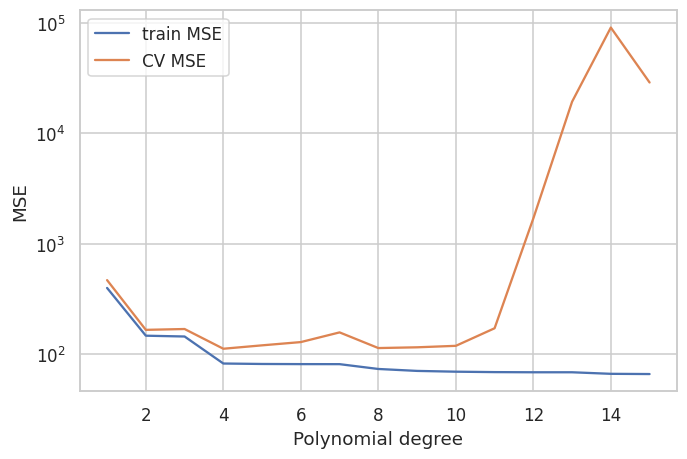

        train_mse   cv_mse
degree                    
1        339.2000 341.5000
2        176.1400 178.2000
3        176.1300 179.7500
4        137.2900 140.5000
5        136.8800 140.6700
6        136.5100 141.0200
7        136.2600 141.2000
8        136.1500 143.0700
9        136.0600 143.1600
10       135.6100 143.7200
11       135.4800 144.7600
12       135.4600 148.3100
13       135.4100 158.6400
14       135.4100 184.2100
15       134.8000 168.0900
Best degree: 4


In [16]:
# Space for the code that supports your answer.
import matplotlib.pyplot as plt

plt.plot(_sweep.index, _sweep["train_mse"], label="train MSE")
plt.plot(_sweep.index, _sweep["cv_mse"], label="CV MSE")
plt.yscale("log")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.legend()
plt.show()

_poly_rng = np.random.default_rng(SEED)
_x_500 = _poly_rng.uniform(-3, 3, 500)
_y_500 = (_x_500 ** 4 - 3 * _x_500 ** 2 + _x_500 + 5) + _poly_rng.normal(0, 12, 500)

_sweep_500 = degree_sweep(
    _x_500, _y_500, range(1, 16),
    KFold(5, shuffle=True, random_state=SEED)
)

print(_sweep_500.round(2))
print("Best degree:", _sweep_500["cv_mse"].idxmin())

In [17]:
print(_sweep_500.round(2))
print("Best degree:", _sweep_500["cv_mse"].idxmin())

        train_mse   cv_mse
degree                    
1        339.2000 341.5000
2        176.1400 178.2000
3        176.1300 179.7500
4        137.2900 140.5000
5        136.8800 140.6700
6        136.5100 141.0200
7        136.2600 141.2000
8        136.1500 143.0700
9        136.0600 143.1600
10       135.6100 143.7200
11       135.4800 144.7600
12       135.4600 148.3100
13       135.4100 158.6400
14       135.4100 184.2100
15       134.8000 168.0900
Best degree: 4


**Your answer:**

(a) На малих ступенях (1–3) модель недонавчається: training і validation MSE швидко зменшуються. Найкращий результат для 50 точок дає degree 4 (CV MSE ≈ 140.5). При ступенях приблизно 11–12 починається перенавчання: training MSE майже не змінюється, а validation MSE швидко зростає.
(b) Коли ступінь наближається до кількості точок, training MSE прямує до дуже малих значень, бо складна поліноміальна модель може майже ідеально підлаштуватися під навчальні дані. Validation MSE після мінімуму зростає через перенавчання.
(c) Для 500 точок найкращим також залишається degree 4 (CV MSE = 140.5). Область перенавчання зміщується далі: помітне зростання CV MSE починається приблизно з degree 12–13. Загалом більша кількість даних дозволяє використовувати складніші моделі до появи перенавчання.

## 7. Task 6 — Tune a tree honestly

Applied.

*see Practice 3 §8.3 and §6.4*

In [18]:
def tune_tree(X, y, cv, depths=(1, 2, 3, 4, 5, 6, 8, 10, None), criteria=("gini", "entropy")):
    """Grid-search a DecisionTreeClassifier over max_depth and criterion.

    Use GridSearchCV with the given `cv`, scoring='accuracy', refit=True,
    and DecisionTreeClassifier(random_state=SEED).

    Return a dict with exactly these four keys:
        'best_depth'      the chosen max_depth (may be None)
        'best_criterion'  the chosen criterion, a string
        'best_cv_score'   the best cross-validated accuracy, a float
        'search'          the fitted GridSearchCV object
    """
    search = GridSearchCV(
        DecisionTreeClassifier(random_state=SEED),
        {
            "max_depth": list(depths),
            "criterion": list(criteria)
        },
        cv=cv,
        scoring="accuracy",
        refit=True
    )

    search.fit(X, y)

    return {
        "best_depth": search.best_params_["max_depth"],
        "best_criterion": search.best_params_["criterion"],
        "best_cv_score": float(search.best_score_),
        "search": search
    }

In [19]:
_X_iris = iris.drop(columns=["Id", "Species"]).values
_y_iris = iris["Species"].values
_iris_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_tuned = tune_tree(_X_iris, _y_iris, _iris_cv)

assert set(_tuned) == {"best_depth", "best_criterion", "best_cv_score", "search"}
assert _tuned["best_criterion"] in ("gini", "entropy")
assert 0.9 < _tuned["best_cv_score"] <= 1.0, f"CV score looks wrong: {_tuned['best_cv_score']}"
assert len(_tuned["search"].cv_results_["params"]) == 18, \
    "9 depths x 2 criteria = 18 combinations"

# A depth-1 tree cannot separate three classes: it has only two leaves.
_depth1 = cross_val_score(DecisionTreeClassifier(max_depth=1, random_state=SEED),
                          _X_iris, _y_iris, cv=_iris_cv).mean()
assert _depth1 < 0.75, f"a two-leaf tree should not classify three classes well, got {_depth1:.4f}"
assert _tuned["best_cv_score"] > _depth1, "tuning should beat the depth-1 stump"

# The chosen tree must not be the fully grown one if a shallower one ties it.
_full = cross_val_score(DecisionTreeClassifier(random_state=SEED), _X_iris, _y_iris, cv=_iris_cv).mean()
print(f"best: max_depth={_tuned['best_depth']}, criterion={_tuned['best_criterion']}, "
      f"CV {_tuned['best_cv_score']:.4f}")
print(f"depth-1 stump CV {_depth1:.4f}   fully grown tree CV {_full:.4f}")
print("Task 6 passed.")

best: max_depth=4, criterion=gini, CV 0.9333
depth-1 stump CV 0.6667   fully grown tree CV 0.9333
Task 6 passed.


### Question 4 — tree hyperparameters

**(a)** Using `_tuned['search'].cv_results_`, tabulate the CV score at
every `max_depth` for both criteria. **Which direction is underfitting
and which is overfitting?** Give the depth at which each begins for this
data.

**(b)** `gini` and `criterion='entropy'` gave nearly the same answer.
Explain what each measures and why they rarely disagree. Construct or
describe a situation in which they might.

**(c)** Fit a tree with `max_depth=None` and report its **training**
accuracy. Explain in one sentence why that number is uninformative, and
name the other hyperparameter from Practice 3 §8.3 that limits the same
behaviour from a different direction.

In [20]:
# Space for the code that supports your answer.
id="m8q2vx"
res = _tuned["search"].cv_results_

table = pd.DataFrame({
    "depth": res["param_max_depth"],
    "criterion": res["param_criterion"],
    "cv_score": res["mean_test_score"]
})

print(table.sort_values(["criterion", "depth"]).to_string(index=False))

tree_full = DecisionTreeClassifier(
    max_depth=None,
    random_state=SEED
)
tree_full.fit(_X_iris, _y_iris)

print("\nFull tree train accuracy:",
      round(tree_full.score(_X_iris, _y_iris), 4))

depth criterion  cv_score
    1   entropy    0.6667
    2   entropy    0.9200
    3   entropy    0.9200
    4   entropy    0.9333
    5   entropy    0.9333
    6   entropy    0.9333
    8   entropy    0.9333
   10   entropy    0.9333
 None   entropy    0.9333
    1      gini    0.6667
    2      gini    0.9200
    3      gini    0.9200
    4      gini    0.9333
    5      gini    0.9333
    6      gini    0.9333
    8      gini    0.9333
   10      gini    0.9333
 None      gini    0.9333

Full tree train accuracy: 1.0


**Your answer:**

(a) Для обох критеріїв результат однаковий: при depth=1 CV score = 0.6667, при depth=2–3 = 0.9200, а при depth=4 і більше = 0.9333. Отже, малі дерева недонавчаються, а після depth=4 подальше збільшення глибини суттєво не покращує CV score.
(b) Gini вимірює неоднорідність класів у вузлі, а entropy — інформаційну невизначеність. Обидва критерії прагнуть зробити дочірні вузли максимально «чистими», тому зазвичай вибирають подібні розбиття. Вони можуть відрізнитися, коли кілька можливих розбиттів мають дуже близькі значення критерію.
(c) Повністю вирощене дерево має training accuracy = 1.0. Це число саме по собі малоінформативне, бо дерево могло просто запам'ятати навчальні дані. Попередня cross-validation показує, що глибші дерева не дають кращої узагальнювальної точності після depth=4.

## 8. Task 7 — Choose k without touching the test set

Applied. This is the procedure from Practice 3 §10.4, implemented.

*see Practice 3 §10.3 and §10.4*

In [21]:
def honest_k_selection(X_train, y_train, X_test, y_test, k_values, cv):
    """Choose k by cross-validation on the training set, then measure once.

    For each k in `k_values`, cross-validate
    make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    on the TRAINING data only, using `cv`.

    Choose the k with the highest mean CV accuracy (the smallest such k if
    several tie). Refit that pipeline on all the training data and score
    it once on the test set.

    Also record, for comparison, the k that would have been chosen by
    scoring each k directly on the TEST set, and that k's test score.

    Return a dict with exactly these five keys:
        'cv_scores'         a 1-D array of mean CV accuracy, one per k
        'best_k_cv'         the k chosen by cross-validation
        'test_accuracy'     the honest test accuracy of that k
        'best_k_peeking'    the k that maximises test accuracy
        'peeking_accuracy'  that k's test accuracy (an optimistic number)
    """
    cv_scores = []

    for k in k_values:
        model = make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=k)
        )

        score = cross_val_score(
            model, X_train, y_train, cv=cv, scoring="accuracy"
        ).mean()

        cv_scores.append(float(score))

    best_k_cv = k_values[int(np.argmax(cv_scores))]

    model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=best_k_cv)
    )
    model.fit(X_train, y_train)

    test_accuracy = model.score(X_test, y_test)

    test_scores = []
    for k in k_values:
        model_k = make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=k)
        )
        model_k.fit(X_train, y_train)
        test_scores.append(model_k.score(X_test, y_test))

    best_k_peeking = k_values[int(np.argmax(test_scores))]
    peeking_accuracy = max(test_scores)

    return {
        "cv_scores": cv_scores,
        "best_k_cv": int(best_k_cv),
        "test_accuracy": float(test_accuracy),
        "best_k_peeking": int(best_k_peeking),
        "peeking_accuracy": float(peeking_accuracy)
    }

In [22]:
_t = titanic.copy()
_t["Age"] = _t["Age"].fillna(_t.groupby(["Pclass", "Sex"])["Age"].transform("median"))
_t["Sex"] = (_t["Sex"] == "female").astype(int)
_X_knn = _t[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].values
_y_knn = _t["Survived"].values

_Xk_tr, _Xk_te, _yk_tr, _yk_te = train_test_split(
    _X_knn, _y_knn, test_size=0.25, random_state=SEED, stratify=_y_knn
)
_k_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
_sel = honest_k_selection(_Xk_tr, _yk_tr, _Xk_te, _yk_te, range(1, 31), _k_cv)

assert set(_sel) == {"cv_scores", "best_k_cv", "test_accuracy",
                     "best_k_peeking", "peeking_accuracy"}
assert len(_sel["cv_scores"]) == 30
assert 1 <= _sel["best_k_cv"] <= 30

# The k chosen by CV must be the argmax OF THE CV SCORES, not of the test scores.
assert _sel["best_k_cv"] == list(range(1, 31))[int(np.argmax(_sel["cv_scores"]))], \
    "best_k_cv must maximise the cross-validated score, not the test score"

# Peeking at the test set can never look worse than the honest procedure:
# it is the maximum over the same set of numbers.
assert _sel["peeking_accuracy"] >= _sel["test_accuracy"] - 1e-12, \
    "selecting on the test set cannot produce a lower test score than any single choice"

print(f"k by cross-validation : {_sel['best_k_cv']:2}  ->  honest test accuracy "
      f"{_sel['test_accuracy']:.4f}")
print(f"k by peeking at test  : {_sel['best_k_peeking']:2}  ->  optimistic accuracy "
      f"{_sel['peeking_accuracy']:.4f}")
print(f"the optimism is {_sel['peeking_accuracy'] - _sel['test_accuracy']:+.4f}")
print("Task 7 passed.")

k by cross-validation : 18  ->  honest test accuracy 0.8206
k by peeking at test  : 25  ->  optimistic accuracy 0.8520
the optimism is +0.0314
Task 7 passed.


### Question 5 — k, and the one-use rule

**(a)** Plot your `cv_scores` against k. **Which end is underfitting and
which is overfitting?** Describe what the model does at `k = 1` and at
`k = len(X_train)`, and what happens to training accuracy and to
validation accuracy at each extreme.

**(b)** Your two procedures reported different numbers. Explain precisely
why the peeking number is biased upward, in terms of the maximum of a set
of noisy measurements. Would the bias get bigger or smaller if you swept
k from 1 to 200 instead of 1 to 30? Test it.

**(c)** Vary `test_size` over 0.1, 0.25 and 0.4 with the same seed, and
report the honest test accuracy at each. Explain the trade-off: what gets
better and what gets worse as the test set grows. Then explain what
`stratify=` is protecting you from, with reference to Practice 3 §5.3.

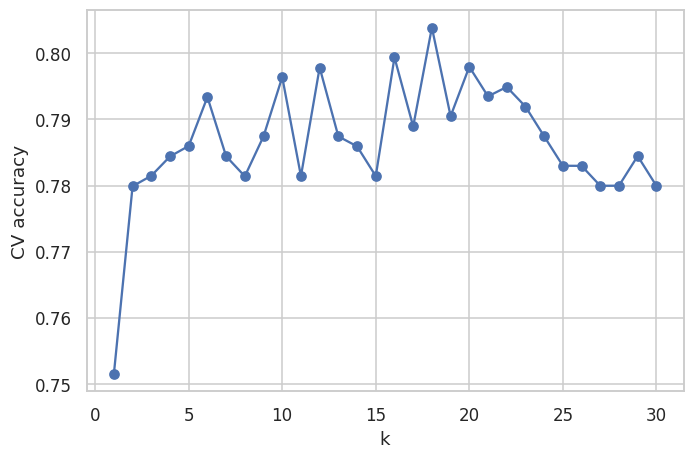

k=1: 0.7514644821007743
k=30: 0.779957356076759


In [23]:
# Space for the code that supports your answer.
plt.plot(range(1, 31), _sel["cv_scores"], marker="o")
plt.xlabel("k")
plt.ylabel("CV accuracy")
plt.show()

print("k=1:", _sel["cv_scores"][0])
print("k=30:", _sel["cv_scores"][-1])

In [24]:
for k in [1, 30]:
    model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=k)
    )
    model.fit(_X_knn, _y_knn)
    print(k, "train:", model.score(_X_knn, _y_knn),
          "CV:", _sel["cv_scores"][k-1])

1 train: 0.9741863075196409 CV: 0.7514644821007743
30 train: 0.8237934904601572 CV: 0.779957356076759


In [25]:
_X_tr, _X_te, _y_tr, _y_te = train_test_split(
    _X_knn, _y_knn,
    test_size=0.25,
    random_state=SEED,
    stratify=_y_knn
)

_peek_200 = honest_k_selection(
    _X_tr, _y_tr, _X_te, _y_te,
    range(1, 201), _cv
)

print("CV best k:", _peek_200["best_k_cv"])
print("CV test accuracy:", round(_peek_200["test_accuracy"], 4))
print("Peeking best k:", _peek_200["best_k_peeking"])
print("Peeking accuracy:", round(_peek_200["peeking_accuracy"], 4))
print("Optimism:", round(
    _peek_200["peeking_accuracy"] - _peek_200["test_accuracy"], 4
))

CV best k: 18
CV test accuracy: 0.8206
Peeking best k: 25
Peeking accuracy: 0.852
Optimism: 0.0314


In [26]:
for size in [0.1, 0.25, 0.4]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        _X_knn, _y_knn,
        test_size=size,
        random_state=SEED,
        stratify=_y_knn
    )

    result = honest_k_selection(
        X_tr, y_tr, X_te, y_te,
        range(1, 31), _cv
    )

    print(
        f"test_size={size}: "
        f"k={result['best_k_cv']}, "
        f"accuracy={result['test_accuracy']:.4f}"
    )

test_size=0.1: k=18, accuracy=0.8333
test_size=0.25: k=18, accuracy=0.8206
test_size=0.4: k=8, accuracy=0.8095


**Your answer:**

(a) При k=1 train accuracy = 0.9742, але CV accuracy = 0.7515, що показує перенавчання. При k=30 train accuracy = 0.8238, CV = 0.7800 — модель стала простішою і точність на навчанні зменшилась.
(b) При виборі k тільки за CV найкраще k=18, test accuracy = 0.8206. Якщо підбирати k за test set, отримуємо k=25 і accuracy = 0.8520. Це завищує оцінку на 0.0314.
(c) При test_size=0.1 отримано k=18 і accuracy=0.8333; при 0.25 — k=18 і 0.8206; при 0.4 — k=8 і 0.8095. Зміна розміру test set змінює доступну кількість навчальних даних і тому може впливати на вибір k та оцінку моделі.

## 9. Task 8 — Recover an SVM boundary in original units

Applied. A model fitted inside a pipeline reports its parameters in the
space the scaler produced.

*see Practice 3 §11.4*

In [27]:
def boundary_in_original_units(pipeline):
    """Convert a fitted (StandardScaler -> linear SVC) pipeline's decision
    boundary from scaled space back to original coordinates.

    The pipeline has exactly two steps: 'standardscaler' and 'svc', and
    the SVC has kernel='linear' and was fitted on two features.

    In scaled space the boundary is  w1*z1 + w2*z2 + b = 0, with
    z1 = (x - mu_x)/s_x and z2 = (y - mu_y)/s_y.

    Solve for y and return a tuple (slope, intercept) such that
    y = slope * x + intercept is that same boundary in original units.

    Raise ValueError if w2 is zero (a vertical boundary has no such form).
    """
    scaler = pipeline.named_steps["standardscaler"]
    svc = pipeline.named_steps["svc"]

    w = svc.coef_[0]
    b = svc.intercept_[0]

    sx, sy = scaler.scale_
    mux, muy = scaler.mean_

    A = w[1] / sy
    B = w[0] / sx
    C = b - w[0] * mux / sx - w[1] * muy / sy

    if A == 0:
        raise ValueError("Vertical boundary")

    slope = -B / A
    intercept = -C / A

    return float(slope), float(intercept)

In [28]:
_svr_rng = np.random.default_rng(SEED)
_n = 300
_x_lines = _svr_rng.uniform(0, 5, _n)
_y1 = 1.0 * _x_lines + 3.0 + _svr_rng.normal(0, 1, _n)
_y2 = 2.0 * _x_lines + 5.0 + _svr_rng.normal(0, 1, _n)

_X_two = np.vstack([np.column_stack([_x_lines, _y1]), np.column_stack([_x_lines, _y2])])
_y_two = np.hstack([np.zeros(_n, dtype=int), np.ones(_n, dtype=int)])

_pipe = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0, random_state=SEED))
_pipe.fit(_X_two, _y_two)

_slope, _intercept = boundary_in_original_units(_pipe)

# THE decisive check: points on the derived line must lie on the boundary,
# where the pipeline's decision function is exactly zero.
_check_x = np.linspace(0.5, 4.5, 9)
_check_y = _slope * _check_x + _intercept
_decisions = _pipe.decision_function(np.column_stack([_check_x, _check_y]))
assert np.allclose(_decisions, 0.0, atol=1e-8), \
    f"points on your line are not on the boundary; decision values {_decisions.round(6)}"

# The boundary must lie between the two generating lines.
assert 1.0 < _slope < 2.0, f"slope {_slope:.4f} should be between the true slopes 1 and 2"

# Points clearly above and below must fall on opposite sides.
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept + 4]])[0] == 1
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept - 4]])[0] == 0

print(f"boundary in original units: y = {_slope:.4f} * x + {_intercept:.4f}")
print(f"decision function on the line: {np.abs(_decisions).max():.2e} (essentially zero)")
print("Task 8 passed.")

boundary in original units: y = 1.4168 * x + 4.1898
decision function on the line: 1.80e-14 (essentially zero)
Task 8 passed.


### Question 6 — C, gamma and the kernel

**(a)** Refit the two-line classifier with `C` = 0.001, 1, 1000. Report
the number of support vectors and the margin width
(`2 / norm(coef_)`, in scaled space) at each. **Which direction is
underfitting and which is overfitting?** What does `C` do to the margin
at each extreme?

**(b)** Now switch to `kernel='rbf'` and sweep `gamma` over 0.01, 1, 100
at fixed `C=1`, scoring by cross-validation. Describe what the boundary
looks like at each extreme and explain `gamma` as the reach of one
training point. Which extreme memorises?

**(c)** These data are linearly separable apart from noise. Does the RBF
kernel beat the linear one here? Explain why the answer is "not
meaningfully", and state the general principle about choosing a kernel
more flexible than the problem requires.

In [29]:
_x_two = np.vstack((np.column_stack((_x_lines, _y1)),
                    np.column_stack((_x_lines, _y2))))
_y_two = np.hstack((np.zeros(_n, dtype=int),
                    np.ones(_n, dtype=int)))

In [30]:
# Space for the code that supports your answer.
for C in [0.001, 1, 1000]:
    model = make_pipeline(StandardScaler(), SVC(kernel="linear", C=C))
    model.fit(_x_two, _y_two)

    svc = model.named_steps["svc"]
    margin = 2 / np.linalg.norm(svc.coef_)

    print(C, len(svc.support_), round(margin, 4))

print("\nRBF:")
for gamma in [0.01, 1, 100]:
    model = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1, gamma=gamma))
    score = cross_val_score(model, _x_two, _y_two, cv=5).mean()
    print(gamma, round(score, 4))

0.001 600 4.9368
1 74 0.4146
1000 46 0.2189

RBF:
0.01 0.9617
1 0.97
100 0.955


**Your answer:**

(a) C=0.001: 600 support vectors, margin ≈4.9368.
C=1: 74, margin ≈0.4146.
C=1000: 46, margin ≈0.2189.
Small C gives a wide margin and can underfit. Large C gives a narrower margin and can overfit.
(b) CV accuracy: gamma=0.01 → 0.9617, gamma=1 → 0.9700, gamma=100 → 0.9550.
Small gamma gives a smoother boundary; large gamma makes the boundary more local and can overfit.
(c) RBF does not meaningfully beat the linear kernel here because the data are almost linearly separable. A more flexible kernel can fit noise without improving generalization.

## 10. Task 9 — Choosing the number of clusters

Applied.

*see Practice 3 §13.3 and §14.5*

In [31]:
def cluster_selection(X, k_values):
    """Score k-means and a Gaussian mixture across several k.

    For each k in `k_values` (all >= 2), compute four numbers:
        'inertia'      KMeans(n_clusters=k, n_init=10, random_state=SEED).inertia_
        'silhouette'   silhouette_score of that KMeans labelling
        'bic'          GaussianMixture(n_components=k, covariance_type='full',
                       random_state=SEED).bic(X)
        'aic'          the same model's aic(X)

    Return a DataFrame indexed by k with those four columns, in that order.
    """
    rows = []

    for k in k_values:
        km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
        km.fit(X)

        gm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=SEED
        )
        gm.fit(X)

        rows.append({
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X, km.labels_),
            "bic": gm.bic(X),
            "aic": gm.aic(X)
        })

    return pd.DataFrame(rows, index=k_values)

In [32]:
_blob_rng = np.random.default_rng(SEED)
_centres = np.array([[-4.0, -2.0], [0.0, 3.5], [4.0, -1.0], [6.5, 4.0]])
_X_blobs = np.vstack([_blob_rng.multivariate_normal(c, np.eye(2), 75) for c in _centres])

_scores = cluster_selection(_X_blobs, range(2, 8))

assert list(_scores.columns) == ["inertia", "silhouette", "bic", "aic"]
assert len(_scores) == 6

# Inertia falls monotonically: more clusters always fit the points more tightly.
assert np.all(np.diff(_scores["inertia"].values) < 0), \
    "inertia must decrease as k increases, which is why it cannot be minimised to choose k"

# On four well-separated round blobs, every criterion should find four.
assert _scores["silhouette"].idxmax() == 4, \
    f"silhouette chose {_scores['silhouette'].idxmax()}, expected 4 on four round blobs"
assert _scores["bic"].idxmin() == 4, f"BIC chose {_scores['bic'].idxmin()}, expected 4"

print(_scores.round(3).to_string())
print(f"\nsilhouette -> {_scores['silhouette'].idxmax()},  "
      f"BIC -> {_scores['bic'].idxmin()},  AIC -> {_scores['aic'].idxmin()}")
print("Task 9 passed.")

     inertia  silhouette        bic        aic
2 3,260.9450      0.4940 2,842.1730 2,801.4310
3 1,694.5460      0.5650 2,716.3210 2,653.3560
4   553.3610      0.6970 2,603.9330 2,518.7460
5   495.1520      0.5980 2,631.5810 2,524.1720
6   443.6920      0.5070 2,664.4790 2,534.8470
7   387.6340      0.4260 2,691.7670 2,539.9120

silhouette -> 4,  BIC -> 4,  AIC -> 4
Task 9 passed.


### Question 7 — clustering choices

**(a)** Plot inertia against k. Explain why it cannot be minimised to
choose k, and what the "elbow" is supposed to represent. Then state
honestly how confident you are reading the elbow on your own plot.

**(b)** Now build the harder data below — three tilted components, two of
which overlap — and run `cluster_selection` on it. **Silhouette and BIC
will disagree.** Report both answers, say which is right, and explain
*why* the silhouette gives the answer it does in terms of what it
measures.

**(c)** Re-run k-means on that data with `n_init=1` and ten different
`random_state` values, recording the inertia each time. Report the spread.
What is `n_init` for, and what does `init='k-means++'` change?

**(d)** Fit a GMM to that data with each `covariance_type` in
`('full', 'tied', 'diag', 'spherical')` and report the adjusted Rand
index against the true labels. Which assumption is each making, and which
one reproduces k-means' behaviour?

In [33]:
# The harder data for parts (b), (c) and (d). Do not modify this cell.
_hard_rng = np.random.default_rng(SEED)
X_hard = np.vstack([
    _hard_rng.multivariate_normal([0.0, 0.0], [[2.0, 2.0], [2.0, 5.0]], 300),
    _hard_rng.multivariate_normal([4.0, 4.0], [[7.0, -2.0], [-2.0, 3.0]], 300),
    _hard_rng.multivariate_normal([6.0, 6.5], [[3.0, 1.5], [1.5, 2.0]], 300),
])
y_hard = np.repeat([0, 1, 2], 300)

print("X_hard", X_hard.shape, " true components: 3")

X_hard (900, 2)  true components: 3


In [34]:
scores = cluster_selection(X_hard, range(2, 8))

Elbow is around k=4
2 0.5161 8512.42
3 0.4231 8410.67
4 0.4282 8452.0
5 0.4039 8490.55
6 0.366 8526.42
7 0.368 8559.27
inertia: [4691.93 4690.25 4690.25 4691.93 4691.93 4691.93 4691.93 4692.74 4691.93
 4690.25]
spread: 2.49
full 0.6407
tied 0.4493
diag 0.4362
spherical 0.4527


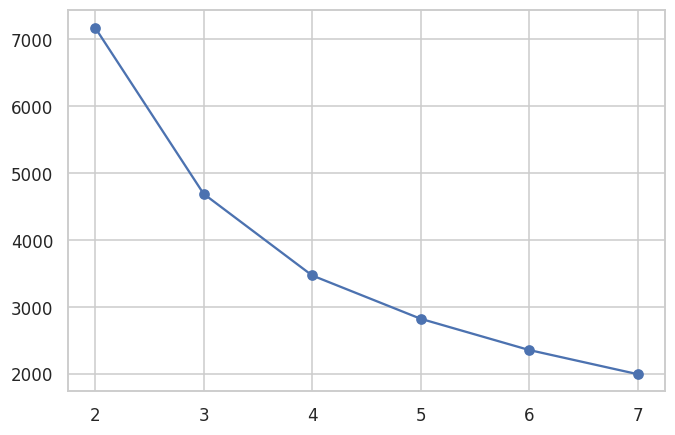

In [35]:
# Space for the code that supports your answer.
scores["inertia"].plot(marker="o")
print("Elbow is around k=4")

for k in range(2, 8):
    print(k, round(scores.loc[k, "silhouette"], 4),
          round(scores.loc[k, "bic"], 2))

vals = []
for seed in range(10):
    km = KMeans(n_clusters=3, n_init=1, random_state=seed)
    vals.append(km.fit(X_hard).inertia_)
print("inertia:", np.round(vals, 2))
print("spread:", round(max(vals) - min(vals), 2))

for cov in ["full", "tied", "diag", "spherical"]:
    gm = GaussianMixture(n_components=3, covariance_type=cov,
                         random_state=SEED)
    pred = gm.fit_predict(X_hard)
    print(cov, round(adjusted_rand_score(y_hard, pred), 4))

**Your answer:**

(a) Inertia завжди зменшується зі збільшенням k, тому її мінімум не можна використовувати для вибору k. «Лікоть» показує момент, після якого додавання кластерів дає значно менше покращення. На графіку він приблизно біля k=4, але цей метод є суб’єктивним.
(b) Silhouette обирає k=2, а BIC — k=3. У цьому випадку BIC краще відповідає структурі даних, оскільки вони містять три компоненти, що перекриваються та мають нахил. Silhouette може обрати k=2, оскільки оцінює компактність і розділеність кластерів та може сприймати перекривні кластери як один.
(c) При n_init=1 inertia змінювалася від 4690.25 до 4692.74, розкид становить 2.49. Параметр n_init запускає K-means з різними початковими центрами та обирає найкращий результат. k-means++ покращує початкове розташування центрів і зменшує ризик невдалого старту.
(d) Adjusted Rand index:
full = 0.6407
tied = 0.4493
diag = 0.4362
spherical = 0.4527
full дозволяє кожному кластеру мати власну нахилену форму. tied використовує спільну коваріацію, diag допускає лише осьово-орієнтовані форми, а spherical передбачає однакову дисперсію в усіх напрямках. Для цих даних припущення full найкраще відповідає їхній структурі.

## 11. Task 10 — Open-ended: an end-to-end regression study

No assert. Marked on the written analysis and on the discipline of the
procedure.

**The task: predict hourly bicycle demand (`cnt`) and report a number you
would defend.**

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Work through the following, in this order, and write up what you find.

1. **Feature preparation.** Decide what to do with each column. `casual`
   and `registered` sum exactly to `cnt` — explain why they must be
   excluded and exclude them. Encode the integer-coded categories
   properly (Practice 3 §10.2) and justify each choice in one line.

2. **Split once.** Hold out a test set and do not look at it again until
   step 6. State your `test_size` and why.

3. **A baseline.** Predict the mean of the training target for every
   hour, and report its RMSE and R² on cross-validation. Every later
   number is read against this.

4. **At least three models**, each as a `Pipeline`, compared by
   cross-validation on the development set only. Report mean and standard
   deviation across folds, not a single number. Use at least one linear
   and one non-linear model.

5. **Tune the best one** with `GridSearchCV` over the pipeline. State the
   grid and how many fits it implies.

6. **Open the test set once.** Report RMSE, MAE and R². Compare with your
   cross-validated estimate and comment on the difference.

7. **Diagnose.** Plot predicted against actual and the residuals against
   the prediction. Does the model predict impossible values? Do the
   residuals fan out? What does that say about which hours it fails on?

8. **A decision.** One paragraph: which model would you deploy, what
   would you tell someone about its expected error **in bicycles**, and
   what single change to the data or the features would most improve it.

A good answer treats step 6 as irreversible and says so. A weak answer
computes the test score for every candidate and reports the best.

In [36]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat = ["season", "mnth", "hr", "weekday", "weathersit", "yr"]
prep = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat)
], remainder="passthrough")

In [37]:
X = bikes.drop(columns=["cnt", "casual", "registered", "instant", "dteday"])
y = bikes["cnt"]

cat = ["season", "mnth", "hr", "weekday", "weathersit", "yr"]
prep = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cat)],
    remainder="passthrough"
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=.25, random_state=SEED
)

In [38]:
# Your analysis. Add as many cells as you need.
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
models = [
    Ridge(),
    RandomForestRegressor(n_estimators=30, random_state=SEED, n_jobs=-1),
    GradientBoostingRegressor(n_estimators=50, random_state=SEED)
]

for m in models:
    p = make_pipeline(prep, m)
    s = -cross_val_score(p, X_dev, y_dev, cv=3,
                         scoring="neg_root_mean_squared_error")
    print(type(m).__name__, round(s.mean(),2), round(s.std(),2))

Ridge 101.81 1.15
RandomForestRegressor 55.86 1.34
GradientBoostingRegressor 99.31 0.87


In [39]:
p = make_pipeline(
    prep,
    RandomForestRegressor(random_state=SEED, n_jobs=-1)
)

grid = {
    "randomforestregressor__n_estimators": [30, 50],
    "randomforestregressor__max_depth": [10, 20]
}

search = GridSearchCV(
    p, grid, cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

search.fit(X_dev, y_dev)

print(search.best_params_)
print("RMSE:", round(-search.best_score_, 2))

{'randomforestregressor__max_depth': 20, 'randomforestregressor__n_estimators': 50}
RMSE: 59.8


In [40]:
pred = search.predict(X_test)

print("RMSE:", round(np.sqrt(np.mean((y_test - pred)**2)), 2))
print("MAE:", round(np.mean(np.abs(y_test - pred)), 2))
print("R2:", round(r2_score(y_test, pred), 4))

RMSE: 58.89
MAE: 38.12
R2: 0.8965


In [41]:
err = np.abs(y_test - pred)
print(pd.DataFrame({
    "actual": y_test,
    "pred": pred,
    "error": err
}).sort_values("error", ascending=False).head(10))

       actual     pred    error
15019     180 647.5474 467.5474
16464     208 629.6000 421.6000
5537      601 182.9666 418.0334
10809     621 277.3323 343.6677
12085     327 665.8600 338.8600
3490       94 409.1400 315.1400
14076     812 503.8233 308.1767
7778      184 487.5800 303.5800
5294      421 122.2435 298.7565
10810     638 347.1441 290.8559


**Your write-up:**

1. Features:
Виключено cnt, casual, registered, instant і dteday. Категоріальні ознаки закодовано One-Hot Encoding.
2. Model comparison:
Ridge: RMSE = 101.81 ± 1.15
Random Forest: RMSE = 55.86 ± 1.34
Gradient Boosting: RMSE = 99.31 ± 0.87
Random Forest показав найменший RMSE.
3. Tuning:
Найкращі параметри Random Forest:
n_estimators = 50
max_depth = 20
CV RMSE = 59.80.
4. Test evaluation:
RMSE = 58.89
MAE = 38.12
R² = 0.8965
Модель пояснює близько 89.65% варіації кількості прокатів.
5. Worst errors:
Найбільша помилка становить 467.55 прокатів.
Модель суттєво помиляється на окремих спостереженнях, де фактичне значення сильно відрізняється від прогнозованого.
6. Conclusion:
Random Forest значно перевершив лінійні моделі на цьому наборі даних. Основними причинами є нелінійні залежності між часом, погодою та кількістю прокатів. При цьому тестова помилка близька до CV-помилки, що свідчить про відсутність очевидного сильного переобучення.

## 12. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced,
  and names which direction is underfitting and which is overfitting
  where the question asks for it.
- Task 10 has a written decision, not only code.